In [2]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from krono import const
import dill as pickle
from scipy.integrate import trapezoid
from importlib import reload

# to make this plot we load the unabridged output: pickled dictionaries containing many emcee.EnsembleSampler and geoid.geoid objects, written by uranus_shape_mcmc.ipynb and neptune_shape_mcmc.ipynb

samplers = {}
import dill as pickle

# Uranus
# sampler that varied only r_pol
with open('/tmp/uranus_sampler_symmetric.pkl', 'rb') as fr:
    samplers['uranus_symmetric'] = {'sampler':pickle.load(fr)}
with open('/tmp/uranus_sampler_composite.pkl', 'rb') as fr:
    samplers['uranus_composite'] = {'sampler':pickle.load(fr)}

# samplers that varied r_pol and wind coefficients
with open('/tmp/uranus_sampler_wind.pkl', 'rb') as fr:
    samplers['uranus_wind'] = {'sampler':pickle.load(fr)}

# skip loading the output of this mcmc exercise; we will load the more meaningful output of results_sample_jn() from uranus_shape_mcmc.ipynb instead.
# # sampler that varied r_pol and jn
# with open('/tmp/uranus_sampler_jn.pkl', 'rb') as fr:
#     samplers['uranus_jn'] = {'sampler':pickle.load(fr)}

# Neptune
# samplers that varied only r_pol
with open('/tmp/neptune_sampler_voyager.pkl', 'rb') as fr:
    samplers['neptune_voy'] = {'sampler':pickle.load(fr)}
with open('/tmp/neptune_sampler_h-band 2014.pkl', 'rb') as fr:
    samplers['neptune_h14'] = {'sampler':pickle.load(fr)}

# samplers that varied r_pol and wind coefficients
with open('/tmp/neptune_sampler_wind_voyager.pkl', 'rb') as fr:
    samplers['neptune_wind_voy'] = {'sampler':pickle.load(fr)}
with open('/tmp/neptune_sampler_wind_h-band 2014.pkl', 'rb') as fr:
    samplers['neptune_wind_h14'] = {'sampler':pickle.load(fr)}

# skip loading the output of this mcmc exercise; we will load the more meaningful output of results_sample_jn() from neptune_shape_mcmc.ipynb instead.
# # sampler that varied r_pol and jn
# with open('/tmp/neptune_sampler_jn.pkl', 'rb') as fr:
#     samplers['neptune_jn'] = {'sampler':pickle.load(fr)}



# collect all the the quantities that matter so we can discard the bulky samplers (~25 GB) in memory, instead keeping scalars totaling ~50 MB
for name, data in samplers.items():
    data['chain'] = data['sampler'].get_chain()
    data['lnp'] = data['sampler'].get_log_prob()

    nstep, nwalk, ndim = data['chain'].shape
    
    # the following are polar and equatorial radii from the geoid objects themselves. north polar radius should be consistent with first parameter in data['chain]
    blobs = data['sampler'].get_blobs()
    data['rp'] = np.array([g.r[ 0] for g in blobs.flatten()]).reshape(nstep, nwalk) # reshaping to be consistent with chain and lnp
    data['rs'] = np.array([g.r[-1] for g in blobs.flatten()]).reshape(nstep, nwalk) # south pole
    data['re'] = np.array([g.r[len(g.mu) // 2] for g in blobs.flatten()]).reshape(nstep, nwalk) # equator

    data.pop('sampler', None)

# see results_sample_jn() in uranus_shape_mcmc.ipynb
uranus_jn_output = np.genfromtxt('models/statistical_samples/uranus_vary_jn.txt', skip_header=4, names=True)
samplers['uranus_jn'] = {'rp':1e5*uranus_jn_output['r_pol_km'], 're':1e5*uranus_jn_output['r_eq_km']}
# same experiment for neptune
neptune_jn_output = np.genfromtxt('models/statistical_samples/neptune_vary_jn.txt', skip_header=4, names=True)
samplers['neptune_jn'] = {'rp':1e5*neptune_jn_output['r_pol_km'], 're':1e5*neptune_jn_output['r_eq_km']}

In [3]:
list(samplers)

['uranus_symmetric',
 'uranus_composite',
 'uranus_wind',
 'neptune_voy',
 'neptune_h14',
 'neptune_wind_voy',
 'neptune_wind_h14',
 'uranus_jn',
 'neptune_jn']

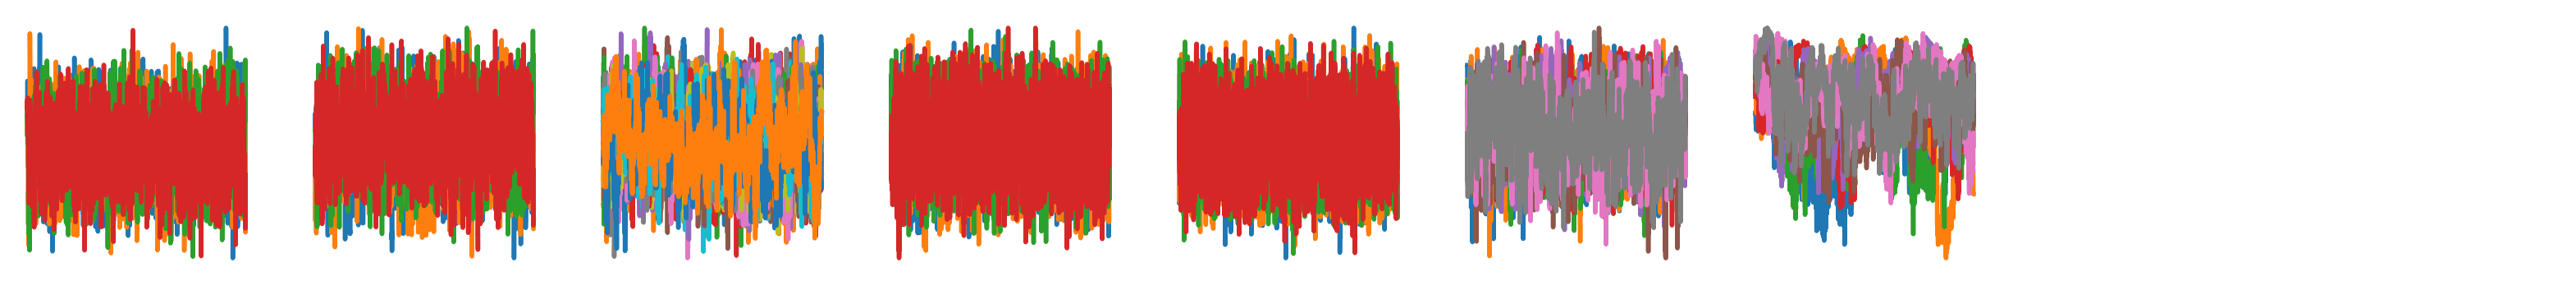

In [4]:
# critical to choose appropriate burn-in for the samplers to get accurate statistics.
# for simplicity choose same burn-in for all
fig, ax = plt.subplots(1, 9, figsize=(20, 2))
nburn = 200
for isampler, (name, data) in enumerate(samplers.items()):
    ax[isampler].axis('off')
    if not 'chain' in data: continue
    for w in data['chain'][nburn:, :, 0].T:
        ax[isampler].plot(w, label=name)
        # break

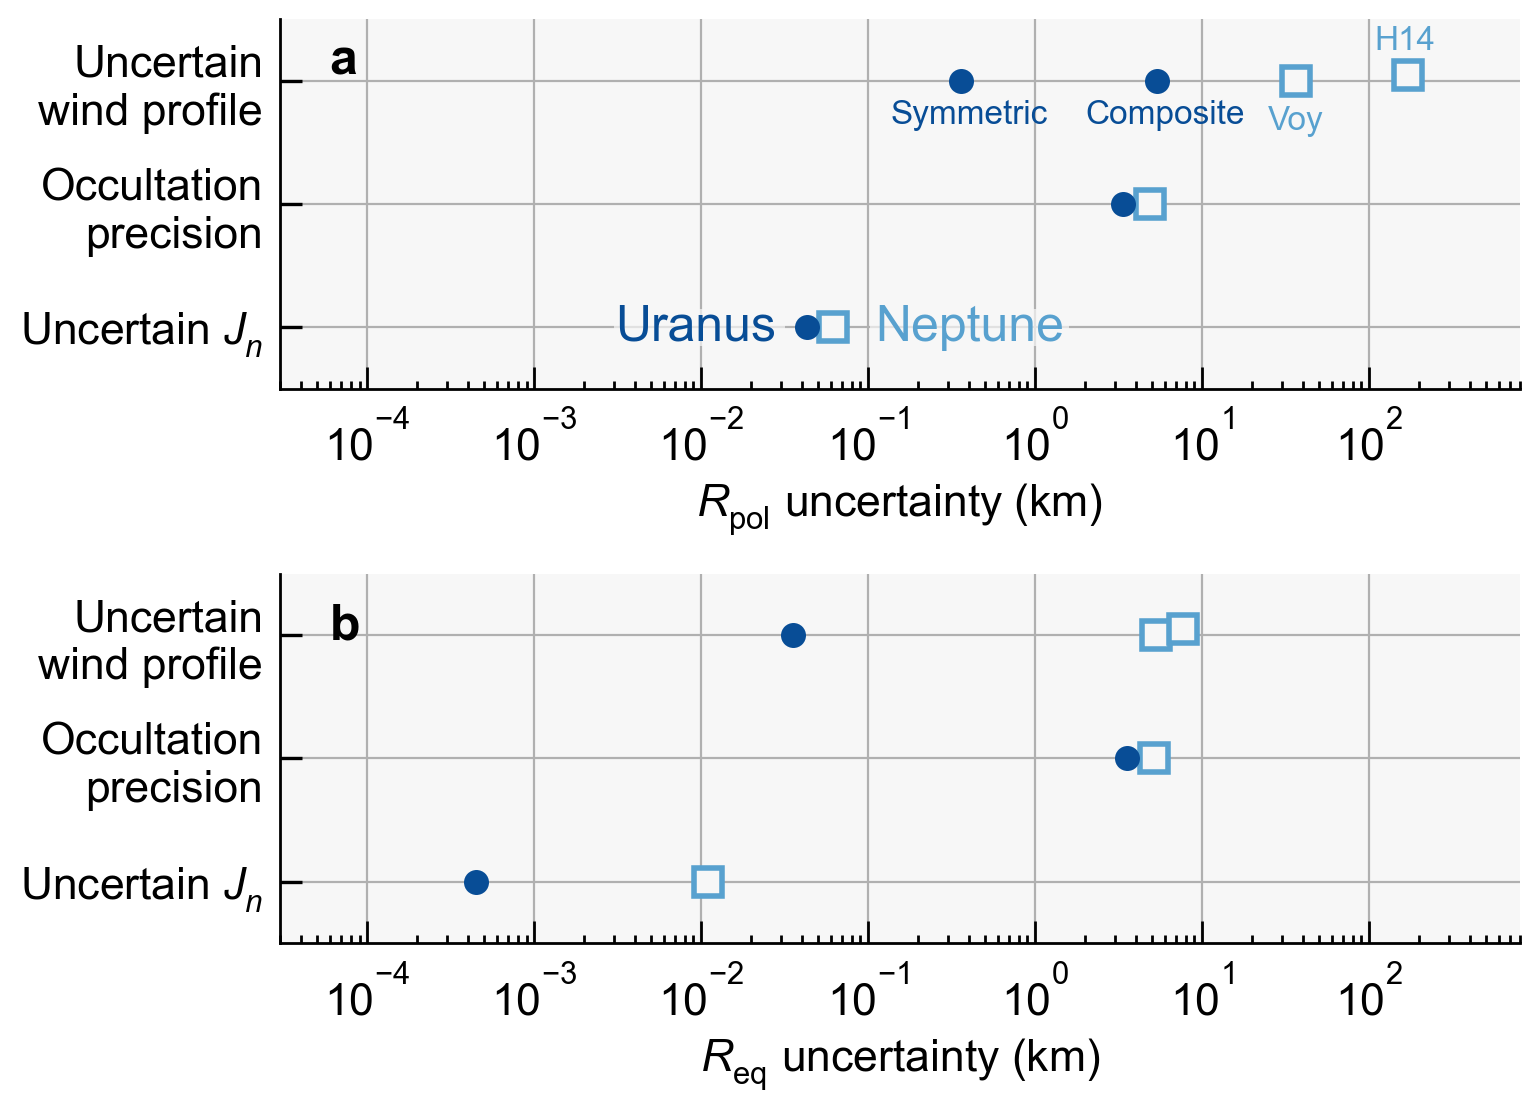

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'hspace':0.5})
# labels = np.array(['Vary winds', r'Vary $R_{\rm occ}$', r'Vary $J_{2n}$'])
# labels = np.array(['Wind profile', 'Occultations', 'Gravity field'])
labels = np.array(['Uncertain\nwind profile', 'Occultation\nprecision', 'Uncertain $J_n$'])
ax[0].set_yticks([0, -1, -2], labels)
ax[1].set_yticks([0, -1, -2], labels)
grey = '#f7f7f7'

# uranus
color = plt.get_cmap('Blues')(0.888)
# color = plt.get_cmap('Purples')(0.777)
spec = {
    'marker':'o',
    'zorder':3,
    'mfc':color,
    'mew':1,
    'mec':'none',
    'ms':9,
}

# 95% quantile for r_pol range given by north versus south polar radius from composite wind fit
rng_rp_vary_winds = np.quantile(samplers['uranus_composite']['rp'][nburn:].flatten() - samplers['uranus_composite']['rs'][nburn:].flatten(), 0.95)
# spread associated with random errors on symmetric wind fit
std_rp_vary_winds = np.std(samplers['uranus_wind']['rp'][nburn:].flatten())
std_re_vary_winds = np.std(samplers['uranus_wind']['re'][nburn:].flatten())
# spread from sigma_Rocc~5 km; probably also just 5km
std_rp_vary_ro = np.std(samplers['uranus_symmetric']['rp'][nburn:].flatten()) # same for composite
std_re_vary_ro = np.std(samplers['uranus_symmetric']['re'][nburn:].flatten()) # same for composite
# spread from jn uncertainties
std_rp_vary_jn = np.std(samplers['uranus_jn']['rp'][nburn:].flatten()) # same for composite
std_re_vary_jn = np.std(samplers['uranus_jn']['re'][nburn:].flatten()) # same for composite

ax[0].plot(1e-5 * rng_rp_vary_winds, 0, **spec)
ax[0].plot(1e-5 * std_rp_vary_winds, 0, **spec)
ax[0].plot(1e-5 * std_rp_vary_ro, -1, **spec)
ax[0].plot(1e-5 * std_rp_vary_jn, -2, **spec)
ax[1].plot(1e-5 * std_re_vary_winds, 0, **spec)
ax[1].plot(1e-5 * std_re_vary_ro, -1, **spec)
ax[1].plot(1e-5 * std_re_vary_jn, -2, **spec)
ax[0].text(2.8e-2, -2, 'Uranus', fontsize=18, ha='right', va='center', color=color)
ax[0].text(4e-1, -0.15, 'Symmetric', fontsize=12, rotation=0, ha='center', va='top', color=color)
ax[0].text(6e0 , -0.15, 'Composite', fontsize=12, rotation=0, ha='center', va='top', color=color)

# write the plotted points to plaintext
with open('models/uncertainties_summary.txt', 'w') as fw:
    fw.write('uncertainties in uranus (u_) and neptune (n_) polar and equatorial radii, in km, considering uncertainties in the input wind profiles, \n')
    fw.write('occultation radii, or zonal gravity moments jn. for a complete description see Mankovich et al. 2026 (PSJ) Section 4.\n')
    fw.write(f"{'u_rp_compositewind_range_polar_asymmetry':40} {1e-5 * rng_rp_vary_winds:.1e}\n")
    fw.write(f"{'u_rp_symmetricwind_stddev_vary_winds':40} {1e-5 * std_rp_vary_winds:.1e}\n")
    fw.write(f"{'u_rp_symmetricwind_stddev_vary_rocc':40} {1e-5 * std_rp_vary_ro:.1e}\n")
    fw.write(f"{'u_rp_symmetricwind_stddev_vary_jn':40} {1e-5 * std_rp_vary_jn:.1e}\n")
    fw.write(f"{'u_re_symmetricwind_stddev_vary_winds':40} {1e-5 * std_re_vary_winds:.1e}\n")
    fw.write(f"{'u_re_symmetricwind_stddev_vary_ro':40} {1e-5 * std_re_vary_ro:.1e}\n")
    fw.write(f"{'u_re_symmetricwind_stddev_vary_jn':40} {1e-5 * std_re_vary_jn:.1e}\n")

# Neptune
color = plt.get_cmap('Blues')(0.555)
# color = plt.get_cmap('Greens')(0.666)
spec = {
    'marker':'s',
    'mfc':grey,
    'mec':color,
    'mew':2,
    'zorder':2,
    'ms':10,
}

# spread associated with random errors on wind fit
std_rp_voy = np.std(samplers['neptune_wind_voy']['rp'][nburn:].flatten())
std_rp_h14 = np.std(samplers['neptune_wind_h14']['rp'][nburn:].flatten())
std_re_voy = np.std(samplers['neptune_wind_voy']['re'][nburn:].flatten())
std_re_h14 = np.std(samplers['neptune_wind_h14']['re'][nburn:].flatten())
# spread from sigma_Rocc=5 km
std_rp_vary_ro = np.std(samplers['neptune_voy']['rp'][nburn:].flatten())
std_re_vary_ro = np.std(samplers['neptune_voy']['re'][nburn:].flatten())
# spread from sigma_jn
std_rp_vary_jn = np.std(samplers['neptune_jn']['rp'][nburn:].flatten())
std_re_vary_jn = np.std(samplers['neptune_jn']['re'][nburn:].flatten())

ax[0].plot(1e-5 * std_rp_voy,  0,    **spec)
ax[0].plot(1e-5 * std_rp_h14,  0.05, **spec)
ax[1].plot(1e-5 * std_re_voy,  0,    **spec)
ax[1].plot(1e-5 * std_re_h14,  0.05, **spec)
ax[0].plot(1e-5 * std_rp_vary_ro, -1, **spec)
ax[1].plot(1e-5 * std_re_vary_ro, -1, **spec)
ax[0].plot(1e-5 * std_rp_vary_jn, -2, **spec)
ax[1].plot(1e-5 * std_re_vary_jn, -2, **spec)

ax[0].text(1.5, -2, 'Neptune', fontsize=18, ha='right', va='center', color=color)
ax[0].text(53, -0.2, 'Voy', fontsize=12, rotation=0, ha='right', va='top', color=color)
ax[0].text(2.5e2, 0.2, 'H14', fontsize=12, rotation=0, ha='right', va='bottom', color=color)

# write the plotted points to plaintext
with open('models/uncertainties_summary.txt', 'a') as fw:
    fw.write(f"{'n_rp_stddev_voyagerwind':40} {1e-5 * std_rp_voy:.1e}\n")
    fw.write(f"{'n_rp_stddev_hband2014wind':40} {1e-5 * std_rp_h14:.1e}\n")
    fw.write(f"{'n_rp_stddev_voyagerwind_vary_ro':40} {1e-5 * std_rp_vary_ro:.1e}\n")
    fw.write(f"{'n_rp_stddev_voyagerwind_vary_jn':40} {1e-5 * std_rp_vary_jn:.1e}\n")
    fw.write(f"{'n_re_stddev_voyagerwind':40} {1e-5 * std_re_voy:.1e}\n")
    fw.write(f"{'n_re_stddev_hband2014wind':40} {1e-5 * std_re_h14:.1e}\n")
    fw.write(f"{'n_re_stddev_voyagerwind_vary_ro':40} {1e-5 * std_re_vary_ro:.1e}\n")
    fw.write(f"{'n_re_stddev_voyagerwind_vary_jn':40} {1e-5 * std_re_vary_jn:.1e}\n")

from matplotlib.patches import Rectangle
x1, x2 = 3e-3, 3.2e-2
y1, y2 = -2.15, -1.85
ax[0].add_artist(Rectangle((x1, y1), x2-x1, y2-y1, facecolor=grey, edgecolor='none', lw=1, zorder=2, alpha=0.7))
x1, x2 = 1.03e-1, 1.6
ax[0].add_artist(Rectangle((x1, y1), x2-x1, y2-y1, facecolor=grey, edgecolor='none', lw=1, zorder=2, alpha=0.7))

# ax.tick_params(left=False, labelleft=False, right=False, which='both')
[z.set_yticks([], minor=True) for z in ax]
[z.tick_params(right=False, top=False, which='both') for z in ax]
ax[0].set_xlabel(r'$R_{\rm pol}$ uncertainty (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ uncertainty (km)')

# ax[0].set_xlim(1e-2, 3e2)
[z.set_xlim(3e-5, 8e2) for z in ax]
[z.set_ylim(-2.5, 0.5) for z in ax]

[z.spines[['right', 'top']].set_visible(False) for z in ax.flatten()]
[z.grid() for z in ax]

for iax, c in enumerate('ab'):
    ax[iax].text(0.04, 0.95 if iax == 0 else 0.92, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)  

[z.set_facecolor(grey) for z in ax]
# [z.spines[['left']].set_visible(False) for z in ax.flatten()]
[z.set_xscale('log') for z in ax]

plt.savefig('figures/un_shape_uncertainties.pdf')


neptune voy rp
24285.812852542287 4.903831955135261
neptune h14 rp
24311.66157772922 4.95062491963338

neptune voy re
24761.88114925619 5.159985671263018
neptune h14 re
24769.397902401066 5.1935957985296115

neptune wind voy rp
24234.585436409376 36.66557899227003
neptune wind h14 rp
24077.840203765227 171.14696749282552

neptune wind voy re
24763.502922832533 5.306449717856131
neptune wind h14 re
24778.722392310337 7.706908787186756

neptune jn rp
24283.48770307879 0.06184515007445899
neptune jn re
24763.558436911113 0.011044052862536855


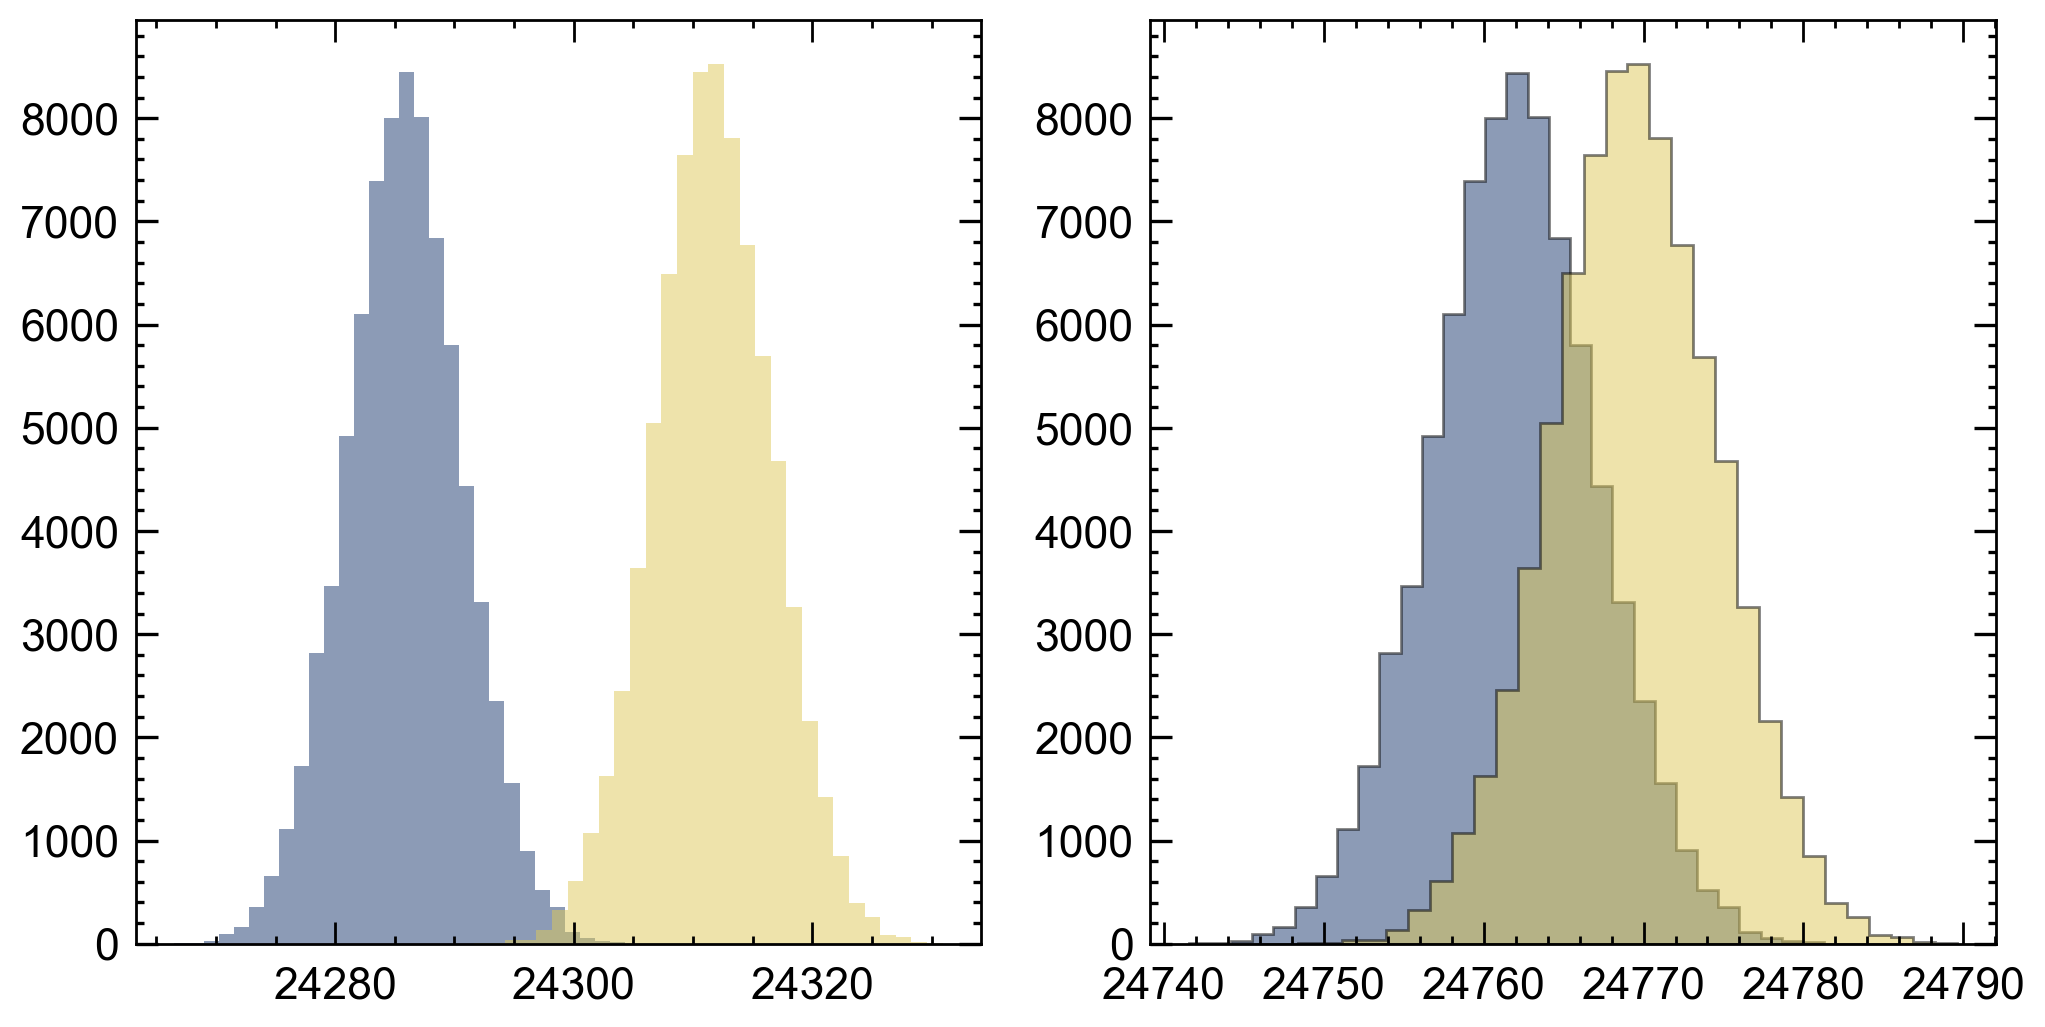

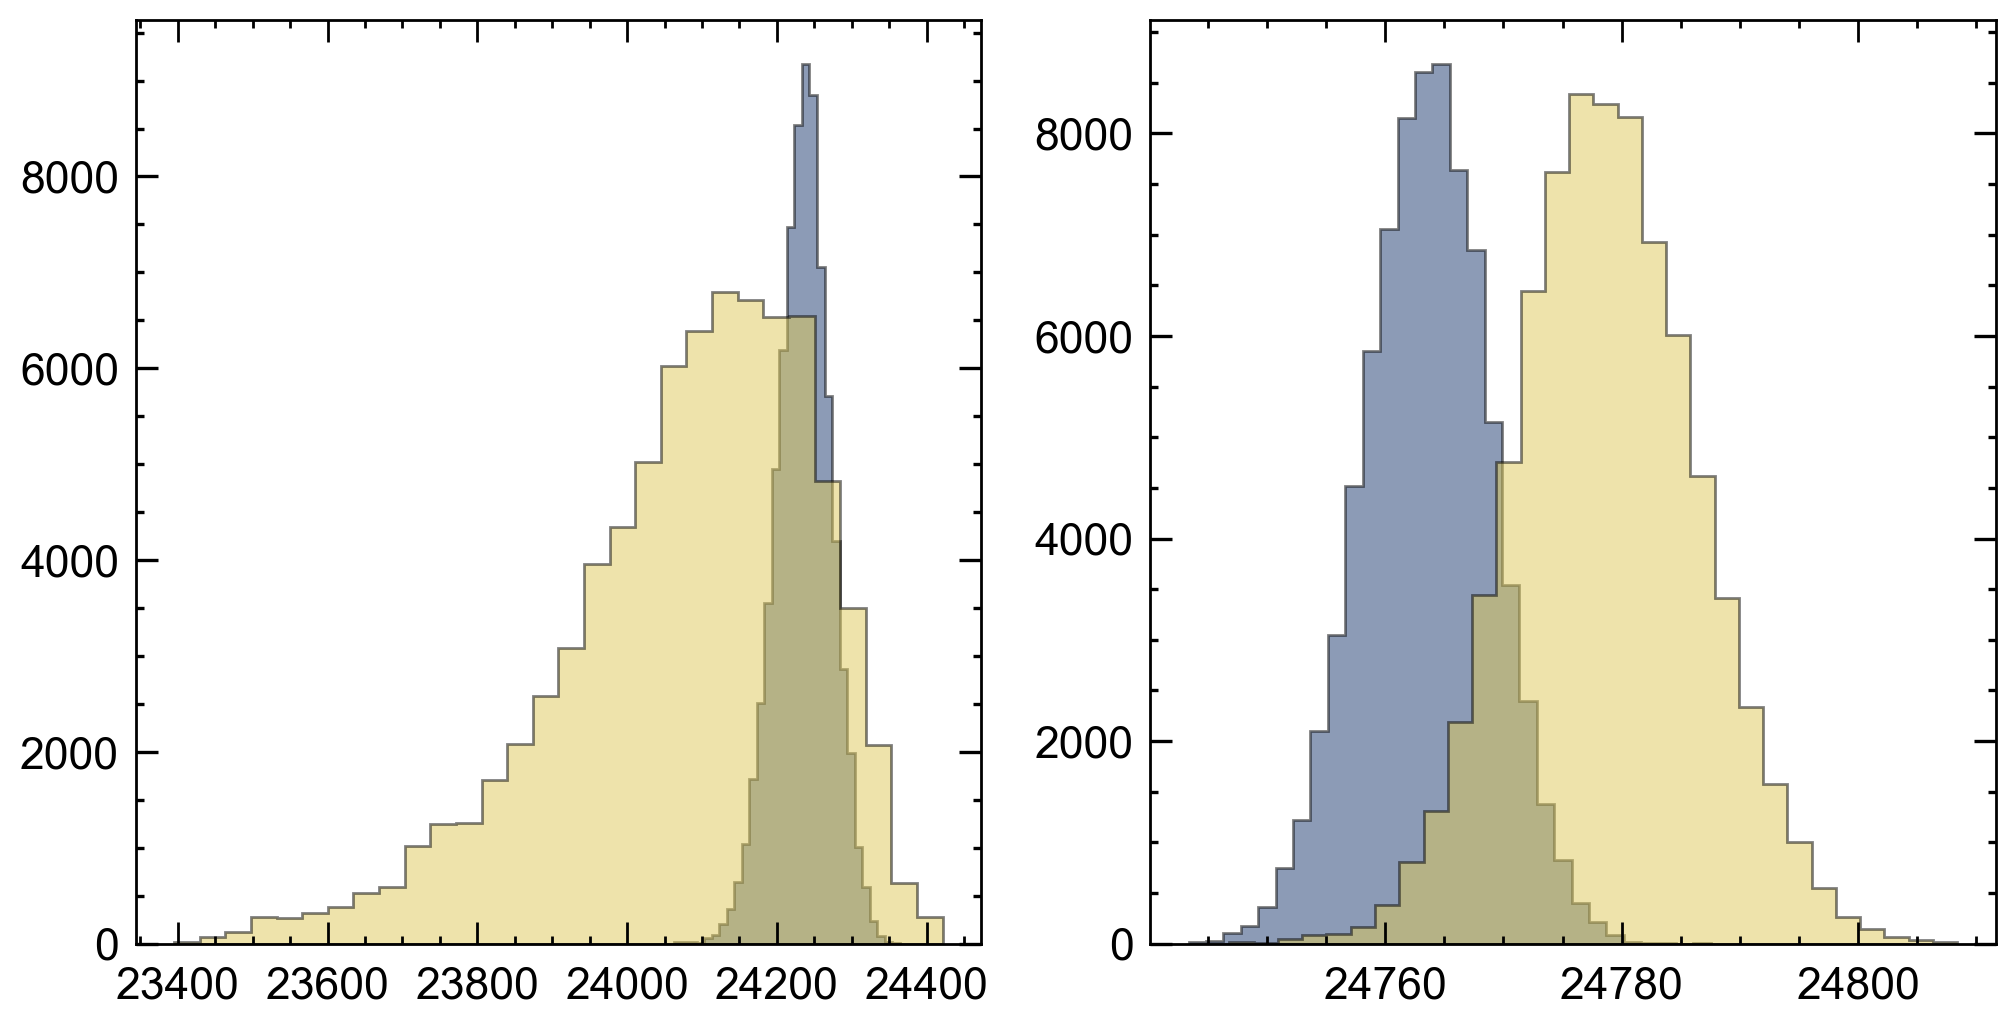

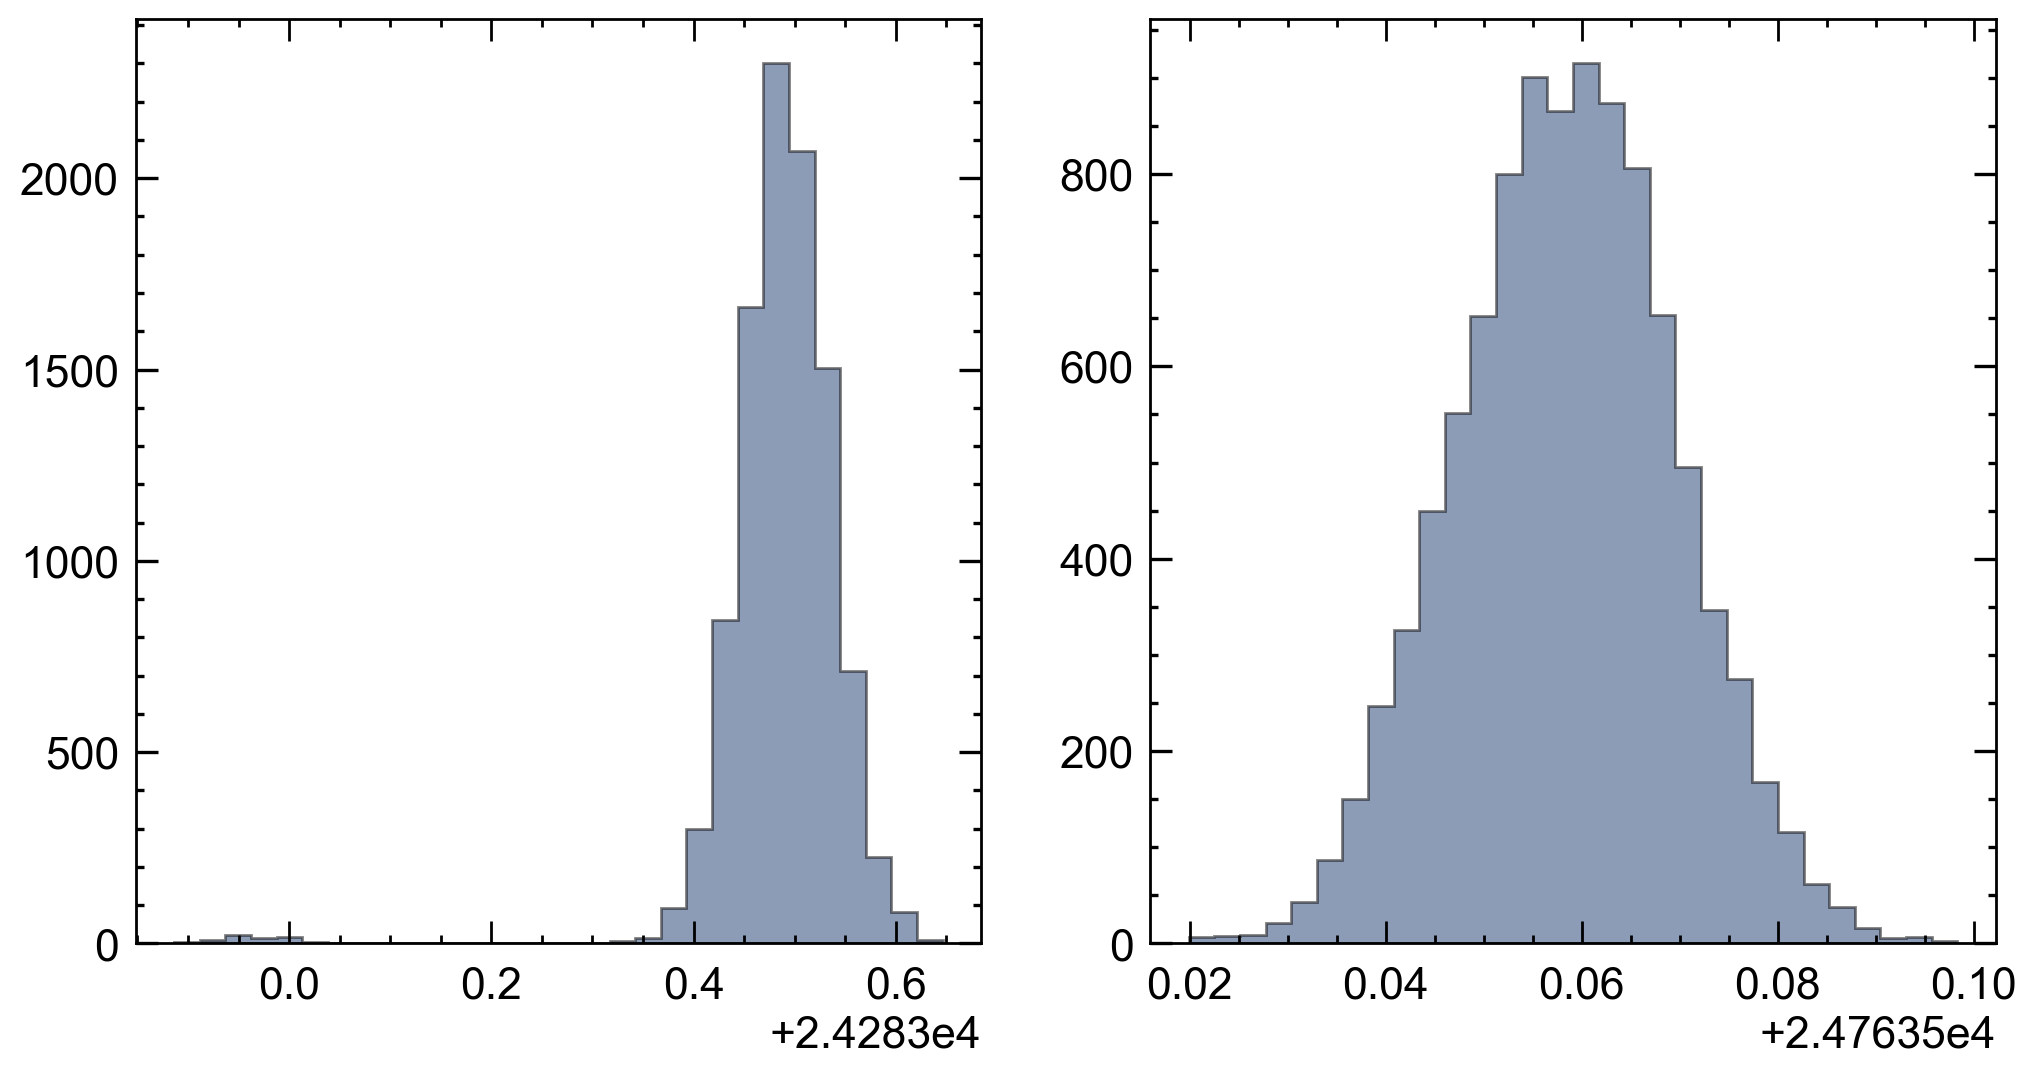

In [16]:

nburn = 100

fig, ax = plt.subplots(1, 2, figsize=(12, 6)) # neptune rp (left) and re (right) when just r_pol is varied
ax[0].hist(1e-5 * samplers['neptune_voy']['rp'][nburn:].flatten(), color=plt.get_cmap('cividis')(1./8), histtype='stepfilled', alpha=0.5, bins=30)
ax[0].hist(1e-5 * samplers['neptune_h14']['rp'][nburn:].flatten(), color=plt.get_cmap('cividis')(7./8), histtype='stepfilled', alpha=0.5, bins=30)
print('neptune voy rp')
print(np.mean(1e-5 * samplers['neptune_voy']['rp'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_voy']['rp'][nburn:].flatten()))
print('neptune h14 rp')
print(np.mean(1e-5 * samplers['neptune_h14']['rp'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_h14']['rp'][nburn:].flatten()))
print()
ax[1].hist(1e-5 * samplers['neptune_voy']['re'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(1./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
ax[1].hist(1e-5 * samplers['neptune_h14']['re'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(7./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
print('neptune voy re')
print(np.mean(1e-5 * samplers['neptune_voy']['re'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_voy']['re'][nburn:].flatten()))
print('neptune h14 re')
print(np.mean(1e-5 * samplers['neptune_h14']['re'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_h14']['re'][nburn:].flatten()))
print()
fig, ax = plt.subplots(1, 2, figsize=(12, 6)) # neptune rp (left) and re (right) when r_pol and wind coefficients are varied
ax[0].hist(1e-5 * samplers['neptune_wind_voy']['rp'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(1./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
ax[0].hist(1e-5 * samplers['neptune_wind_h14']['rp'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(7./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
print('neptune wind voy rp')
print(np.mean(1e-5 * samplers['neptune_wind_voy']['rp'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_wind_voy']['rp'][nburn:].flatten()))
print('neptune wind h14 rp')
print(np.mean(1e-5 * samplers['neptune_wind_h14']['rp'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_wind_h14']['rp'][nburn:].flatten()))
print()
ax[1].hist(1e-5 * samplers['neptune_wind_voy']['re'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(1./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
ax[1].hist(1e-5 * samplers['neptune_wind_h14']['re'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(7./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
print('neptune wind voy re')
print(np.mean(1e-5 * samplers['neptune_wind_voy']['re'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_wind_voy']['re'][nburn:].flatten()))
print('neptune wind h14 re')
print(np.mean(1e-5 * samplers['neptune_wind_h14']['re'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_wind_h14']['re'][nburn:].flatten()))
print()
fig, ax = plt.subplots(1, 2, figsize=(12, 6)) # neptune rp (left) and re (right) when jn are varied
ax[0].hist(1e-5 * samplers['neptune_jn']['rp'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(1./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
ax[1].hist(1e-5 * samplers['neptune_jn']['re'][nburn:].flatten(), facecolor=plt.get_cmap('cividis')(1./8), edgecolor='k', histtype='stepfilled', alpha=0.5, bins=30)
print('neptune jn rp')
print(np.mean(1e-5 * samplers['neptune_jn']['rp'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_jn']['rp'][nburn:].flatten()))
print('neptune jn re')
print(np.mean(1e-5 * samplers['neptune_jn']['re'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_jn']['re'][nburn:].flatten()))


In [16]:
print(' uranus vary jn rp:', np.mean(1e-5 * samplers[ 'uranus_jn']['rp'][nburn:].flatten()), np.std(1e-5 * samplers[ 'uranus_jn']['rp'][nburn:].flatten()))
print(' uranus vary jn re:', np.mean(1e-5 * samplers[ 'uranus_jn']['re'][nburn:].flatten()), np.std(1e-5 * samplers[ 'uranus_jn']['re'][nburn:].flatten()))
print('neptune vary jn rp:', np.mean(1e-5 * samplers['neptune_jn']['rp'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_jn']['rp'][nburn:].flatten()))
print('neptune vary jn re:', np.mean(1e-5 * samplers['neptune_jn']['re'][nburn:].flatten()), np.std(1e-5 * samplers['neptune_jn']['re'][nburn:].flatten()))


 uranus vary jn rp: 24968.867349248485 0.0431713960938099
 uranus vary jn re: 25556.62035090909 0.0004485832488210256
neptune vary jn rp: 24283.48770307879 0.06184515007445899
neptune vary jn re: 24763.558436911113 0.011044052862536855
